Import libraries and load dataset

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/content/drive/MyDrive/Data Analyst/Linear regression/AAPL.csv")
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400


 Check the dataset

In [6]:
df.shape

(9909, 7)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       9909 non-null   object 
 1   Open       9909 non-null   float64
 2   High       9909 non-null   float64
 3   Low        9909 non-null   float64
 4   Close      9909 non-null   float64
 5   Adj Close  9909 non-null   float64
 6   Volume     9909 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 542.0+ KB


In [8]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,9909.000000,9909.000000,9909.000000,9909.000000,9909.000000,9.909000e+03
mean,32.606849,32.936079,32.277560,32.618030,30.576570,8.582916e+07
std,58.415759,59.001576,57.883037,58.471899,56.746275,8.597195e+07
min,0.198661,0.198661,0.196429,0.196429,0.155638,3.472000e+05
25%,1.071429,1.089286,1.048571,1.071429,0.917643,3.304230e+07
50%,1.729286,1.758929,1.696429,1.732143,1.466154,5.766490e+07
75%,35.799999,36.265713,35.328571,35.761429,31.042374,1.069992e+08
max,324.739990,327.850006,323.350006,327.200012,327.200012,1.855410e+09


check missing values

In [9]:
df.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0


Convert Date into date format

In [10]:
df['Date']

,Date
0,1980-12-12
1,1980-12-15
2,1980-12-16
3,1980-12-17
4,1980-12-18
...,...
9904,2020-03-26
9905,2020-03-27
9906,2020-03-30
9907,2020-03-31


In [11]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']


,Date
0,1980-12-12
1,1980-12-15
2,1980-12-16
3,1980-12-17
4,1980-12-18
...,...
9904,2020-03-26
9905,2020-03-27
9906,2020-03-30
9907,2020-03-31


In [12]:

df = df.sort_values('Date')
print(df)

           Date        Open        High         Low       Close   Adj Close  \
0    1980-12-12    0.513393    0.515625    0.513393    0.513393    0.406782   
1    1980-12-15    0.488839    0.488839    0.486607    0.486607    0.385558   
2    1980-12-16    0.453125    0.453125    0.450893    0.450893    0.357260   
3    1980-12-17    0.462054    0.464286    0.462054    0.462054    0.366103   
4    1980-12-18    0.475446    0.477679    0.475446    0.475446    0.376715   
...         ...         ...         ...         ...         ...         ...   
9904 2020-03-26  246.520004  258.679993  246.360001  258.440002  258.440002   
9905 2020-03-27  252.750000  255.869995  247.050003  247.740005  247.740005   
9906 2020-03-30  250.740005  255.520004  249.399994  254.809998  254.809998   
9907 2020-03-31  255.600006  262.489990  252.000000  254.289993  254.289993   
9908 2020-04-01  246.500000  248.720001  239.130005  240.910004  240.910004   

         Volume  
0     117258400  
1      43971200

create daily return

In [13]:
df['Daily_Return'] = df['Adj Close'].pct_change()
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,NaN
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073395
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986
...,...,...,...,...,...,...,...,...
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800,0.052623
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200,-0.041402
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100,0.028538
9907,2020-03-31,255.600006,262.489990,252.000000,254.289993,254.289993,49250500,-0.002041


create target:

In [14]:
df['Target_Next_Day_Close'] = df['Adj Close'].shift(-1)
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close
0,1980-12-12,0.513393,0.515625,0.513393,0.513393,0.406782,117258400,NaN,0.385558
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,0.357260
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073395,0.366103
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,0.376715
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,0.399707
...,...,...,...,...,...,...,...,...,...
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800,0.052623,247.740005
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200,-0.041402,254.809998
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100,0.028538,254.289993
9907,2020-03-31,255.600006,262.489990,252.000000,254.289993,254.289993,49250500,-0.002041,240.910004


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9909 entries, 0 to 9908
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   9909 non-null   datetime64[ns]
 1   Open                   9909 non-null   float64       
 2   High                   9909 non-null   float64       
 3   Low                    9909 non-null   float64       
 4   Close                  9909 non-null   float64       
 5   Adj Close              9909 non-null   float64       
 6   Volume                 9909 non-null   int64         
 7   Daily_Return           9908 non-null   float64       
 8   Target_Next_Day_Close  9908 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 696.9 KB


remove null

In [16]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9907 entries, 1 to 9907
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   9907 non-null   datetime64[ns]
 1   Open                   9907 non-null   float64       
 2   High                   9907 non-null   float64       
 3   Low                    9907 non-null   float64       
 4   Close                  9907 non-null   float64       
 5   Adj Close              9907 non-null   float64       
 6   Volume                 9907 non-null   int64         
 7   Daily_Return           9907 non-null   float64       
 8   Target_Next_Day_Close  9907 non-null   float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 774.0 KB


In [17]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,0.357260
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073395,0.366103
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,0.376715
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,0.399707
5,1980-12-19,0.504464,0.506696,0.504464,0.504464,0.399707,12157600,0.061033,0.419162
...,...,...,...,...,...,...,...,...,...
9903,2020-03-25,250.750000,258.250000,244.300003,245.520004,245.520004,75900500,-0.005509,258.440002
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800,0.052623,247.740005
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200,-0.041402,254.809998
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100,0.028538,254.289993


create year column

In [18]:
df['Year'] = df['Date'].dt.year
df

/tmp/ipykernel_2038/3822126121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Year'] = df['Date'].dt.year


,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close,Year
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,0.357260,1980
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073395,0.366103,1980
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,0.376715,1980
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,0.399707,1980
5,1980-12-19,0.504464,0.506696,0.504464,0.504464,0.399707,12157600,0.061033,0.419162,1980
...,...,...,...,...,...,...,...,...,...,...
9903,2020-03-25,250.750000,258.250000,244.300003,245.520004,245.520004,75900500,-0.005509,258.440002,2020
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800,0.052623,247.740005,2020
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200,-0.041402,254.809998,2020
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100,0.028538,254.289993,2020


EDA Chart 1 — Adjusted Close Price

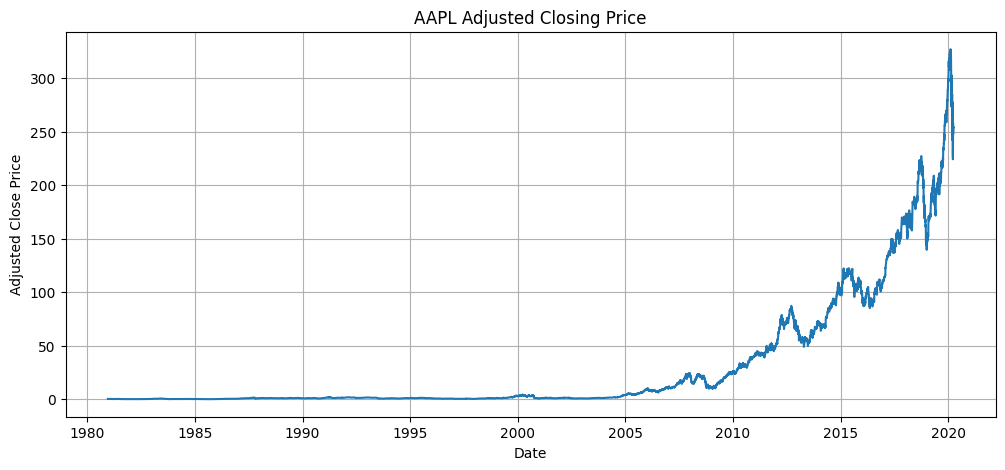

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['Adj Close'])

plt.title('AAPL Adjusted Closing Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')

plt.grid(True)
plt.show()

Observation

The adjusted closing price shows the long-term movement of Apple stock. Overall, the stock shows a strong upward trend over the dataset period, although there are periods of increases and decreases.

EDA Chart 2 — Trading Volume

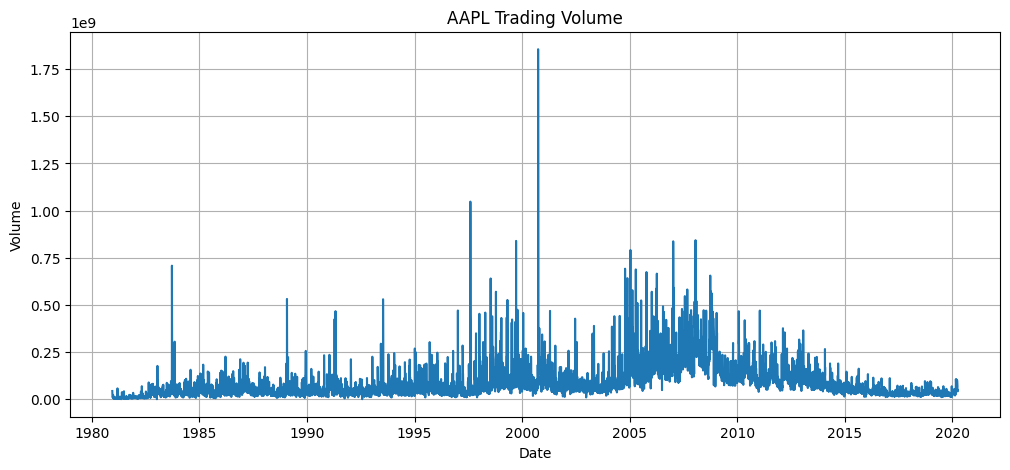

In [20]:
plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['Volume'])

plt.title('AAPL Trading Volume')
plt.xlabel('Date')
plt.ylabel('Volume')

plt.grid(True)
plt.show()

Trading volume changes significantly over time. Large spikes in volume indicate periods when many shares were traded.

EDA Chart 3 — Daily Return Distribution

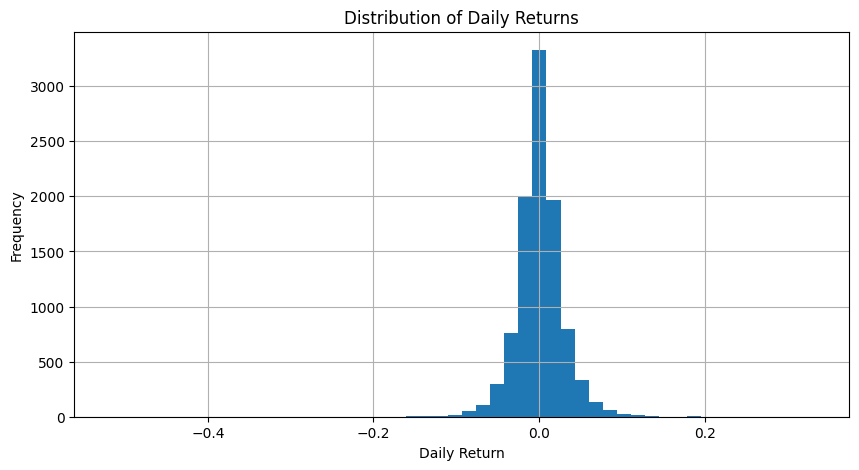

In [21]:
plt.figure(figsize=(10, 5))

plt.hist(df['Daily_Return'].dropna(), bins=50)

plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')

plt.grid(True)
plt.show()

Observation

Most daily returns are close to zero, meaning the stock usually does not change by a very large percentage in a single trading day. A few extreme values represent unusually large price movements.

EDA Chart 4 — High vs Low Price

This shows the difference between the highest and lowest price during each trading day.

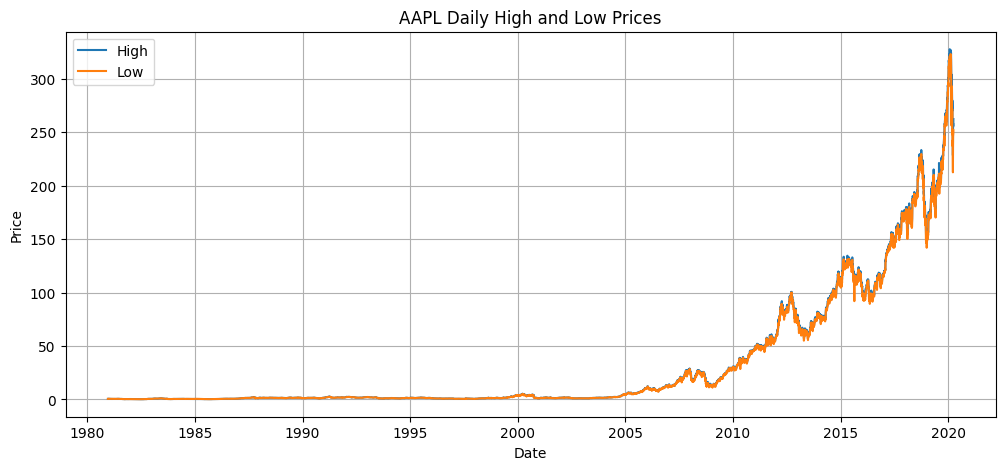

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(df['Date'], df['High'], label='High')
plt.plot(df['Date'], df['Low'], label='Low')

plt.title('AAPL Daily High and Low Prices')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)
plt.show()

Observation

The high and low prices generally move together. The distance between them shows the amount of price movement within each trading day.

Year-wise Analysis

Now we calculate yearly information.

In [23]:
yearly = df.groupby('Year').agg(
    Start_Price=('Adj Close', 'first'),
    End_Price=('Adj Close', 'last'),
    Highest_Price=('Adj Close', 'max'),
    Lowest_Price=('Adj Close', 'min'),
    Average_Price=('Adj Close', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()

In [24]:
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close,Year
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,0.357260,1980
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073395,0.366103,1980
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,0.376715,1980
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,0.399707,1980
5,1980-12-19,0.504464,0.506696,0.504464,0.504464,0.399707,12157600,0.061033,0.419162,1980
...,...,...,...,...,...,...,...,...,...,...
9903,2020-03-25,250.750000,258.250000,244.300003,245.520004,245.520004,75900500,-0.005509,258.440002,2020
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800,0.052623,247.740005,2020
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200,-0.041402,254.809998,2020
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100,0.028538,254.289993,2020


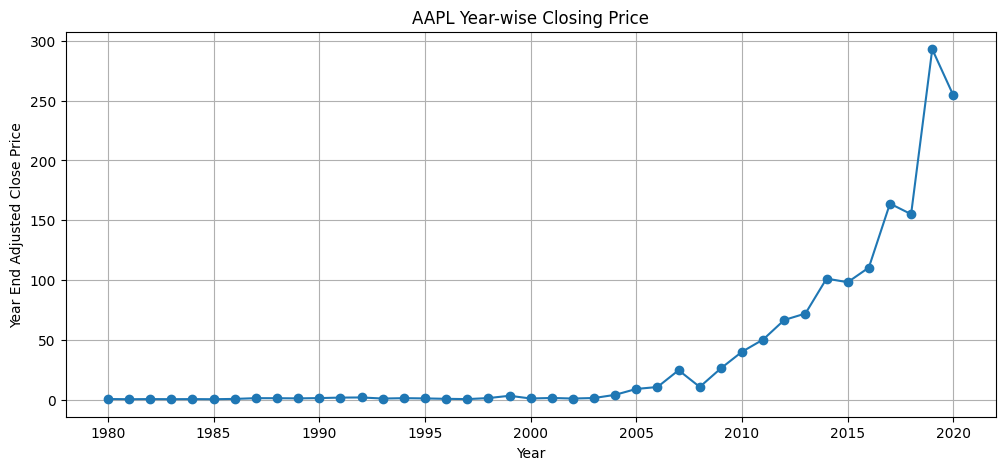

In [25]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly['Year'],
    yearly['End_Price'],
    marker='o'
)

plt.title('AAPL Year-wise Closing Price')
plt.xlabel('Year')
plt.ylabel('Year End Adjusted Close Price')

plt.grid(True)
plt.show()

Observation

The chart helps examine whether trading volume and stock price have a relationship. The points are widely distributed, so volume alone does not directly determine the stock's adjusted closing price.

year wise analysis

In [26]:
yearly = df.groupby('Year').agg(
    Start_Price=('Adj Close', 'first'),
    End_Price=('Adj Close', 'last'),
    Highest_Price=('Adj Close', 'max'),
    Lowest_Price=('Adj Close', 'min'),
    Average_Price=('Adj Close', 'mean'),
    Total_Volume=('Volume', 'sum')
).reset_index()
yearly.head()

,Year,Start_Price,End_Price,Highest_Price,Lowest_Price,Average_Price,Total_Volume
0,1980,0.385558,0.482832,0.509361,0.357260,0.432721,218954400
1,1981,0.488138,0.313045,0.488138,0.201622,0.343975,2049236000
2,1982,0.311276,0.422699,0.479295,0.155638,0.270850,5341252000
3,1983,0.403244,0.344880,0.887845,0.252912,0.530151,11128252800
4,1984,0.362566,0.412087,0.470452,0.309508,0.379218,10494758400


Calculate Yearly Return

In [27]:
yearly['Yearly_Return'] = (
    (yearly['End_Price'] - yearly['Start_Price'])
    / yearly['Start_Price']
) * 100
df

,Date,Open,High,Low,Close,Adj Close,Volume,Daily_Return,Target_Next_Day_Close,Year
1,1980-12-15,0.488839,0.488839,0.486607,0.486607,0.385558,43971200,-0.052174,0.357260,1980
2,1980-12-16,0.453125,0.453125,0.450893,0.450893,0.357260,26432000,-0.073395,0.366103,1980
3,1980-12-17,0.462054,0.464286,0.462054,0.462054,0.366103,21610400,0.024752,0.376715,1980
4,1980-12-18,0.475446,0.477679,0.475446,0.475446,0.376715,18362400,0.028986,0.399707,1980
5,1980-12-19,0.504464,0.506696,0.504464,0.504464,0.399707,12157600,0.061033,0.419162,1980
...,...,...,...,...,...,...,...,...,...,...
9903,2020-03-25,250.750000,258.250000,244.300003,245.520004,245.520004,75900500,-0.005509,258.440002,2020
9904,2020-03-26,246.520004,258.679993,246.360001,258.440002,258.440002,63021800,0.052623,247.740005,2020
9905,2020-03-27,252.750000,255.869995,247.050003,247.740005,247.740005,51054200,-0.041402,254.809998,2020
9906,2020-03-30,250.740005,255.520004,249.399994,254.809998,254.809998,41994100,0.028538,254.289993,2020


In [28]:
yearly[['Year', 'Start_Price', 'End_Price', 'Yearly_Return']]

,Year,Start_Price,End_Price,Yearly_Return
0,1980,0.385558,0.482832,25.229360
1,1981,0.488138,0.313045,-35.869532
2,1982,0.311276,0.422699,35.795381
3,1983,0.403244,0.344880,-14.473669
4,1984,0.362566,0.412087,13.658567
5,1985,0.394401,0.311276,-21.076180
6,1986,0.314814,0.573032,82.022483
7,1987,0.578337,1.194453,106.532364
8,1988,1.272662,1.154425,-9.290557
9,1989,1.158009,1.020944,-11.836308


Year-wise Line Plot

This is the year-wise analysis line plot

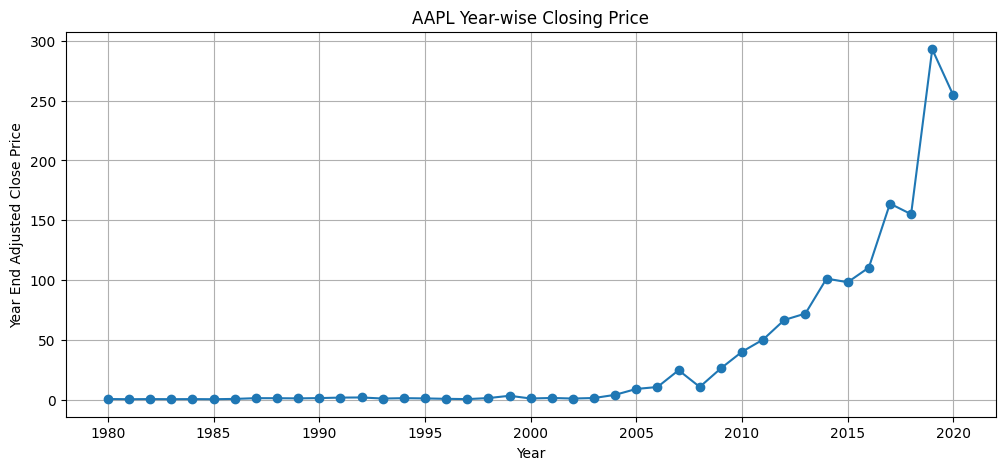

In [29]:
plt.figure(figsize=(12, 5))

plt.plot(
    yearly['Year'],
    yearly['End_Price'],
    marker='o'
)

plt.title('AAPL Year-wise Closing Price')
plt.xlabel('Year')
plt.ylabel('Year End Adjusted Close Price')

plt.grid(True)
plt.show()

Observation

The year-end adjusted closing price generally increases over the long term, although some years show decreases. This indicates long-term growth with short-term fluctuations.

Year-wise Return Chart

This is useful for seeing which years performed better or worse.



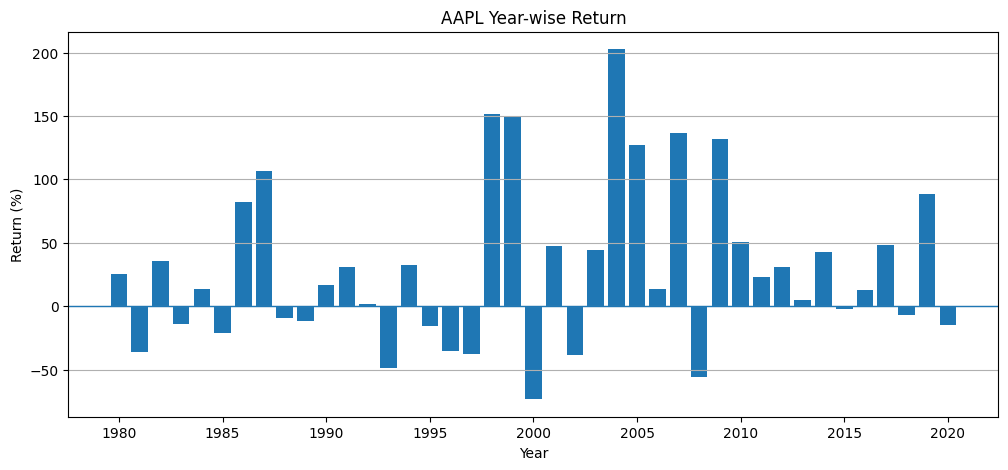

In [30]:
plt.figure(figsize=(12, 5))

plt.bar(
    yearly['Year'],
    yearly['Yearly_Return']
)

plt.title('AAPL Year-wise Return')
plt.xlabel('Year')
plt.ylabel('Return (%)')

plt.axhline(0, linewidth=1)

plt.grid(axis='y')
plt.show()

Observation

Positive bars represent years when the stock increased from the beginning to the end of the year. Negative bars represent years when the stock decreased.

Moving Average Calculation

A moving average helps smooth the stock price and makes the overall trend easier to see.

Let's calculate a 20-day moving average and 50-day moving average.

In [31]:
df['MA_20'] = df['Adj Close'].rolling(window=20).mean()
print(df['MA_20'])

df['MA_50'] = df['Adj Close'].rolling(window=50).mean()
print(df['MA_50'])

1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
           ...    
9903    265.268500
9904    264.514500
9905    263.233501
9906    261.033501
9907    259.282001
Name: MA_20, Length: 9907, dtype: float64
1              NaN
2              NaN
3              NaN
4              NaN
5              NaN
           ...    
9903    295.480643
9904    294.410649
9905    293.153393
9906    291.959721
9907    290.686013
Name: MA_50, Length: 9907, dtype: float64


/tmp/ipykernel_2038/487586480.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA_20'] = df['Adj Close'].rolling(window=20).mean()
/tmp/ipykernel_2038/487586480.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['MA_50'] = df['Adj Close'].rolling(window=50).mean()


Moving Average Chart

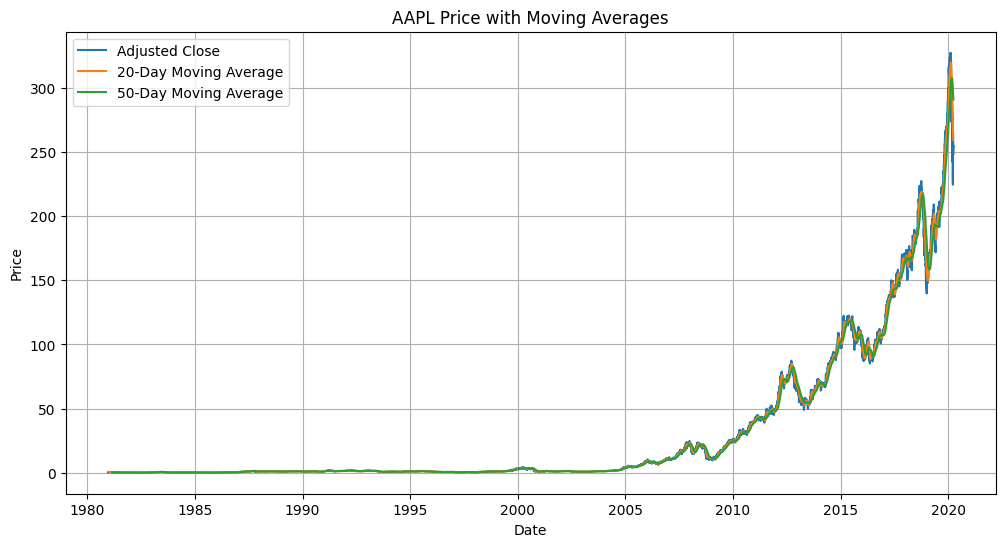

In [32]:
plt.figure(figsize=(12, 6))

plt.plot(
    df['Date'],
    df['Adj Close'],
    label='Adjusted Close'
)

plt.plot(
    df['Date'],
    df['MA_20'],
    label='20-Day Moving Average'
)

plt.plot(
    df['Date'],
    df['MA_50'],
    label='50-Day Moving Average'
)

plt.title('AAPL Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price')

plt.legend()
plt.grid(True)
plt.show()

Observation

The moving averages smooth out daily price fluctuations. The 20-day moving average reacts faster to recent price changes, while the 50-day moving average changes more slowly and shows the longer-term trend.

Profit and Loss Calculation

For a simple example, suppose you invest $1,000 at the beginning of the dataset and hold the stock until the end.

First:

1. Difference between Close and Adj Close

Adj Close (Adjusted Close) adjusts the closing price for things such as stock splits and dividends.

So:Close tells us the actual closing market price, while Adj Close gives us a price adjusted for corporate actions.

Close = final market trading price for that day
There isn't a formula like an average.
For example:Last traded price of the day = $150
Close = $150
Adjusted Close
Conceptually:
Adjusted Close = historical Close adjusted for dividends and stock splits
The exact adjustment is calculated by the data provider using the company's corporate-action history.
So you generally do not calculate Adj Close yourself. Your CSV already provides it.

difference between loc and iloc

loc is used to select rows and columns using labels,
eg:df.loc[0:4, ['Date', 'Close', 'Adj Close']]

This means:Select rows 0 through 4 and the Date, Close, and Adj Close columns.

While iloc is used to select rows and columns using their integer position.
eg:first_price = df['Adj Close'].iloc[0]

Here:df['Adj Close']selects the Adj Close column.Then:.iloc[0]selects the first value from that column.

A moving average calculates the average price over a specific number of previous days. The rolling window determines how many days are used for each calculation. For example, a 10-day moving average uses the previous 10 prices to calculate the average.example in my case:
df['MA_10'] = df['Adj Close'].rolling(10).mean()

What does it mean?
df['MA_10']

creates a new column called MA_10.

df['Adj Close']

uses Apple's adjusted closing price.

.rolling(10)

takes 10 trading days at a time.

.mean()

calculates the average of those 10 prices.

So:

10 prices → average → MA_10

Then it moves one day forward:

Next 10 prices → average → next MA_10

In [36]:
initial_investment = float(input("Enter your investment amount: "))

start_year = int(input("Enter starting year: "))

end_year = int(input("Enter ending year: "))

year_data = df[
    (df['Year'] >= start_year) &
    (df['Year'] <= end_year)
]

first_price = year_data['Adj Close'].iloc[0]

last_price = year_data['Adj Close'].iloc[-1]

shares = initial_investment / first_price

final_value = shares * last_price

profit_loss = final_value - initial_investment

profit_loss_percent = (profit_loss / initial_investment) * 100

print("Initial Investment:", initial_investment)
print("Start Year:", start_year)
print("End Year:", end_year)
print("First Price:", first_price)
print("Last Price:", last_price)
print("Number of Shares:", shares)
print("Final Value:", final_value)
print("Profit/Loss:", profit_loss)
print("Profit/Loss Percentage:", profit_loss_percent)

Enter your investment amount: 1000
Enter starting year: 2010
Enter ending year: 2015
Initial Investment: 1000.0
Start Year: 2010
End Year: 2015
First Price: 26.538482666015625
Last Price: 98.12966918945312
Number of Shares: 37.681129421938266
Final Value: 3697.636764859771
Profit/Loss: 2697.636764859771
Profit/Loss Percentage: 269.7636764859771
